In [1]:
%load_ext autoreload
%autoreload 2

# WeatherBench2 Sample Plots

Plot sample forecasts from trained post-processing models against the verifying observation.
Covers 2m temperature and 10m wind speed over Germany.

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from genpp import BASE_DIR
from genpp.data.weatherbench2 import (
    FC_VARS,
    OBSERVATIONS_FLAT_PATH,
    TEST_PREDICTIONS,
)
from genpp.eval import best_models
from genpp.eval.utils import load_predictions_dataarray
from genpp.plots import RESULTS_DIR

## Load Data

Load observations from the flat zarr store and set up prediction coordinates.

In [3]:
weatherbench_dir = BASE_DIR / "data" / "weatherbench2"

# Prediction index from test split
prediction_index = TEST_PREDICTIONS
init_times = prediction_index.get_level_values("time")
lead_offsets = prediction_index.get_level_values("prediction_timedelta")
lead_hours = np.asarray(lead_offsets / np.timedelta64(1, "h"), dtype=int)
valid_times = init_times + lead_offsets

print(f"Number of test predictions: {len(prediction_index)}")
print(f"Init times range: {init_times.min()} - {init_times.max()}")
print(f"Lead hours: {np.unique(lead_hours)}")

Number of test predictions: 3620
Init times range: 2022-01-01 00:00:00 - 2022-12-30 12:00:00
Lead hours: [ 24  48  72  96 120]


In [4]:
# Load observations (verifying analysis)
obs_ds = xr.open_dataset(OBSERVATIONS_FLAT_PATH)
obs = (
    obs_ds.sel(time=valid_times)
    .to_dataarray("feature")
    .sel(feature=FC_VARS)
    .transpose("time", "feature", "longitude", "latitude")
)
print("Observations shape:", obs.shape)

Observations shape: (3620, 2, 37, 31)


## Trained Model Predictions

Load validation predictions from best trained models and compare them to the verifying observation.

In [5]:
# Discover and load model predictions
model_predictions: dict[str, dict[str, xr.DataArray]] = {}

for model_name, model_entries in best_models:
    if not model_entries:
        continue
    model_predictions[model_name] = {}

    # For EMOS and DRN: only load ECC and GCA copula variants
    if model_name in ("emos", "drn"):
        entry = model_entries[0]
        for copula_tag, copula_file in [
            ("ecc", "test_predictions_ecc.zarr"),
            ("gca", "test_predictions_gca.zarr"),
        ]:
            try:
                copula_path = entry.model_dir / copula_file
                if not copula_path.exists():
                    found = list(entry.model_dir.rglob(copula_file))
                    if not found:
                        print(f"  ✗ {model_name}/{copula_tag}: {copula_file} not found")
                        continue
                    copula_path = found[0]
                preds = load_predictions_dataarray(copula_path).sel(prediction=TEST_PREDICTIONS)
                model_predictions[model_name][copula_tag] = preds
                n_samples = preds.sizes.get("sample", 1)
                print(f"  ✓ {model_name}/{copula_tag}: {preds.shape}  ({n_samples} samples)")
            except Exception as e:
                print(f"  ✗ {model_name}/{copula_tag}: {e}")
    else:
        # All other models: load test_predictions variants
        for entry in model_entries:
            variant_key = entry.tag or "standard"
            try:
                pred_files = list(entry.model_dir.rglob("test_predictions*.zarr"))
                if not pred_files:
                    print(f"  ✗ {model_name}/{variant_key}: no prediction file found")
                    continue
                preds = load_predictions_dataarray(pred_files[0]).sel(prediction=TEST_PREDICTIONS)
                model_predictions[model_name][variant_key] = preds
                n_samples = preds.sizes.get("sample", 1)
                print(f"  ✓ {model_name}/{variant_key}: {preds.shape}  ({n_samples} samples)")
            except Exception as e:
                print(f"  ✗ {model_name}/{variant_key}: {e}")

print(f"\nLoaded models: {list(model_predictions.keys())}")
for mname, variants in model_predictions.items():
    print(f"  {mname}: {list(variants.keys())}")

  ✓ emos/ecc: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ emos/gca: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ drn/ecc: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ drn/gca: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/ind_es: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/ind_pes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/ind_mses: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/ind_mspes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/dir_es: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/dir_pes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/dir_mses: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/dir_mspes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ fm/ind_unet: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ fm/dir_unet: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ fm/ind_uvit: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ fm/dir_uvit: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ engression/ind_es: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ engression/ind_pes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ engression/ind_mses: (3620, 50,

### Select Model, Variant and Prediction

Change the values in the cell below to select which model, variant, and prediction to plot.

In [26]:
# ── Configuration ──────────────────────────────────────────
# Change these values to select what to plot:
SELECTED_MODEL = "chen"  # one of: emos, drn, chen, engression, fm
SELECTED_VARIANT = "ind_es"  # variant tag (or "standard" for single-variant models)
SELECTED_PRED_IDX = 4  # index into TEST_PREDICTIONS
N_SAMPLES_SHOW = 4  # number of generated samples to display
# ───────────────────────────────────────────────────────────

# Print available options for reference
print("Available models / variants:")
for mname, variants in model_predictions.items():
    print(f"  {mname}: {list(variants.keys())}")

print(f"\nSelected: {SELECTED_MODEL} / {SELECTED_VARIANT}")
sel_pred = prediction_index[SELECTED_PRED_IDX]
sel_init = sel_pred[0]
sel_lead = sel_pred[1]
sel_lead_h = int(sel_lead / np.timedelta64(1, "h"))
sel_valid = sel_init + sel_lead
print(
    f"Prediction: init {pd.Timestamp(sel_init):%Y-%m-%d %HZ}  +{sel_lead_h}h  (valid {pd.Timestamp(sel_valid):%Y-%m-%d %HZ})"
)

Available models / variants:
  emos: ['ecc', 'gca']
  drn: ['ecc', 'gca']
  chen: ['ind_es', 'ind_pes', 'ind_mses', 'ind_mspes', 'dir_es', 'dir_pes', 'dir_mses', 'dir_mspes']
  fm: ['ind_unet', 'dir_unet', 'ind_uvit', 'dir_uvit']
  engression: ['ind_es', 'ind_pes', 'ind_mses', 'ind_mspes', 'dir_es', 'dir_pes', 'dir_mses', 'dir_mspes']

Selected: chen / ind_es
Prediction: init 2022-01-01 00Z  +120h  (valid 2022-01-06 00Z)


### Model Samples vs Observation

For each forecast variable, plot the observation alongside several generated samples from the selected model.

In [27]:
# Fetch the selected model predictions
model_da = model_predictions[SELECTED_MODEL][SELECTED_VARIANT]
model_sel = model_da.sel(prediction=sel_pred)

# Determine the sample/member dimension name
if "sample" in model_sel.dims:
    sample_dim = "sample"
elif "number" in model_sel.dims:
    sample_dim = "number"
elif "member" in model_sel.dims:
    sample_dim = "member"
else:
    sample_dim = None

if sample_dim is not None:
    n_avail = model_sel.sizes[sample_dim]
    n_show = min(N_SAMPLES_SHOW, n_avail)
    sample_ids = model_sel[sample_dim].values[:n_show]
    print(f"Showing {n_show}/{n_avail} samples (dim='{sample_dim}')")
else:
    n_show = 0
    sample_ids = []
    print("Model output is deterministic (single forecast)")

# Reference observation for this prediction
# Use isel to handle duplicate valid times (different init+lead can map to same valid time)
obs_sel = obs.sel(time=sel_valid)
if "time" in obs_sel.dims:
    obs_sel = obs_sel.isel(time=0)
lon = obs_sel.longitude
lat = obs_sel.latitude

Showing 4/50 samples (dim='sample')


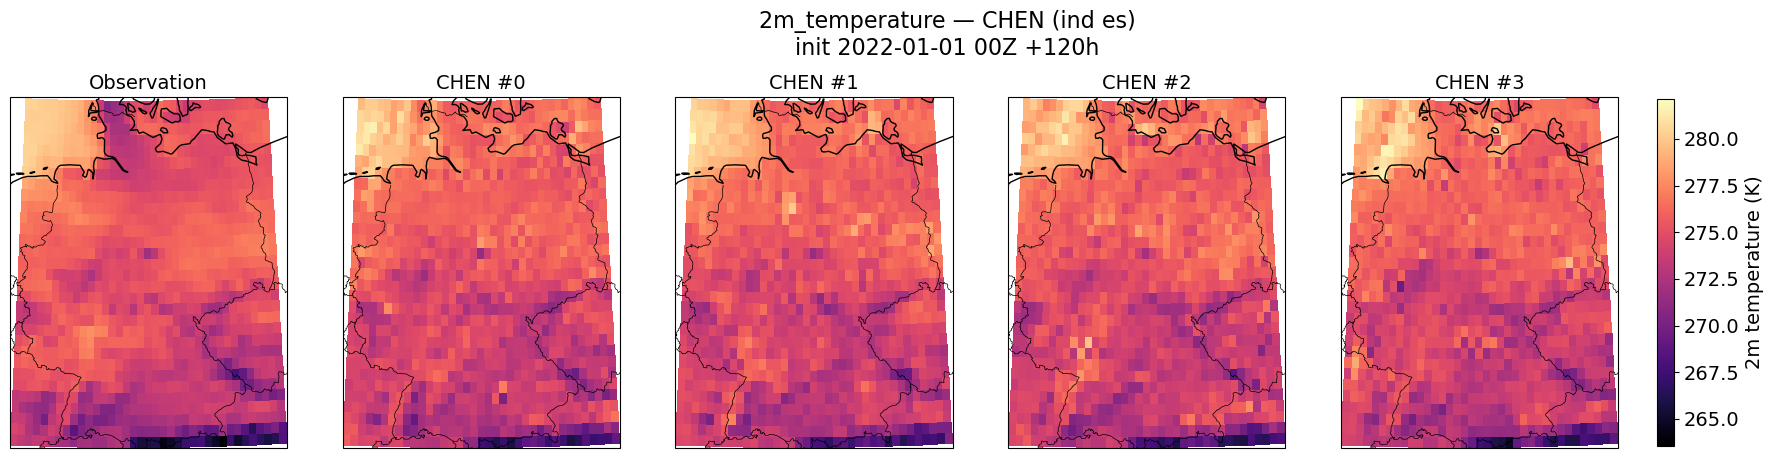

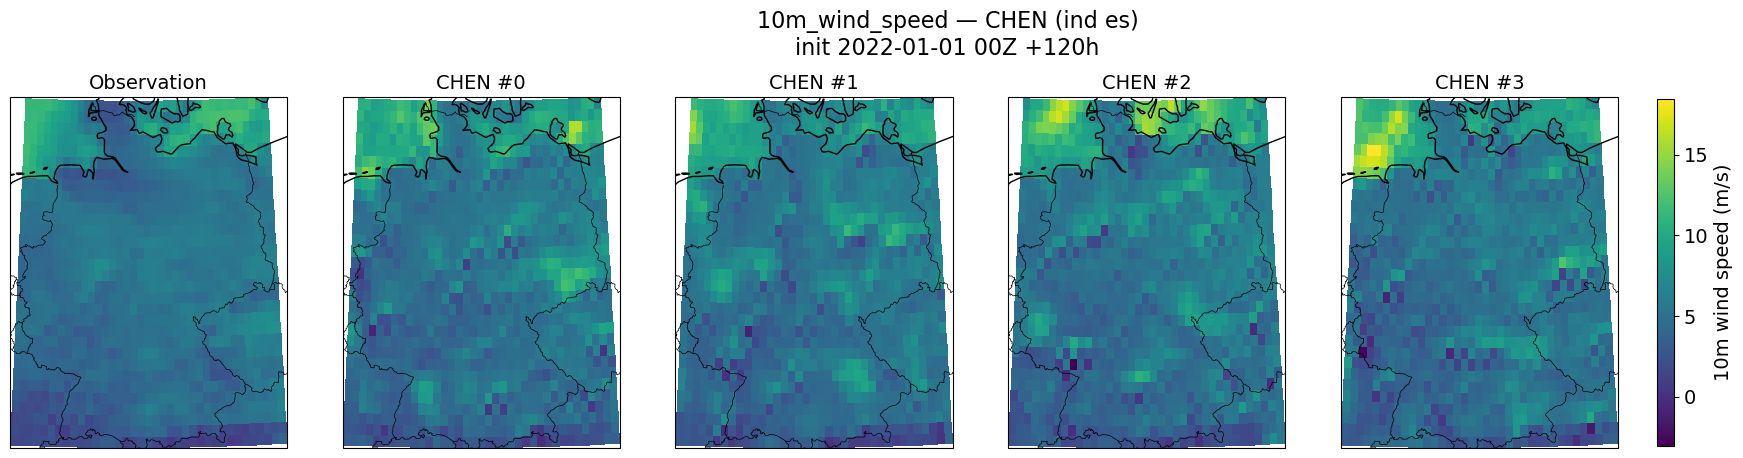

In [28]:
var_settings = {
    "2m_temperature": {"cmap": "magma", "label": "2m temperature (K)"},
    "10m_wind_speed": {"cmap": "viridis", "label": "10m wind speed (m/s)"},
}

proj = ccrs.LambertConformal(central_longitude=10, central_latitude=51)

for var in FC_VARS:
    cfg = var_settings[var]

    # Gather arrays to plot: obs + model samples
    obs_v = obs_sel.sel(feature=var)

    if sample_dim is not None and n_show > 0:
        model_samples = [model_sel.sel(feature=var, **{sample_dim: s}) for s in sample_ids]
    else:
        model_samples = [model_sel.sel(feature=var)]

    all_data = [obs_v] + model_samples
    titles = ["Observation"] + [f"{SELECTED_MODEL.upper()} #{i}" for i in range(len(model_samples))]

    # Shared colour limits
    all_vals = np.concatenate([d.values.ravel() for d in all_data])
    vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))

    n_cols = len(all_data)
    fig, axes = plt.subplots(
        1,
        n_cols,
        figsize=(5 * n_cols, 5),
        subplot_kw={"projection": proj},
    )
    if n_cols == 1:
        axes = [axes]

    for ax, da, title in zip(axes, all_data, titles):
        pcm = ax.pcolormesh(
            lon,
            lat,
            da.T,
            cmap=cfg["cmap"],
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree(),
            shading="auto",
            rasterized=True,
        )
        ax.coastlines(resolution="50m")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.set_title(title, fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(
        pcm,
        ax=list(axes),
        orientation="vertical",
        label=cfg["label"],
        shrink=0.9,
        pad=0.02,
    )
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(cfg["label"], fontsize=14)

    variant_label = SELECTED_VARIANT.replace("_", " ")
    fig.suptitle(
        f"{var} — {SELECTED_MODEL.upper()} ({variant_label})\n"
        f"init {pd.Timestamp(sel_init):%Y-%m-%d %HZ} +{sel_lead_h}h",
        fontsize=16,
        y=1.02,
    )
    plt.show()

### All Models — Single Sample Comparison

One sample from each model (first variant, first sample) side-by-side with the observation.

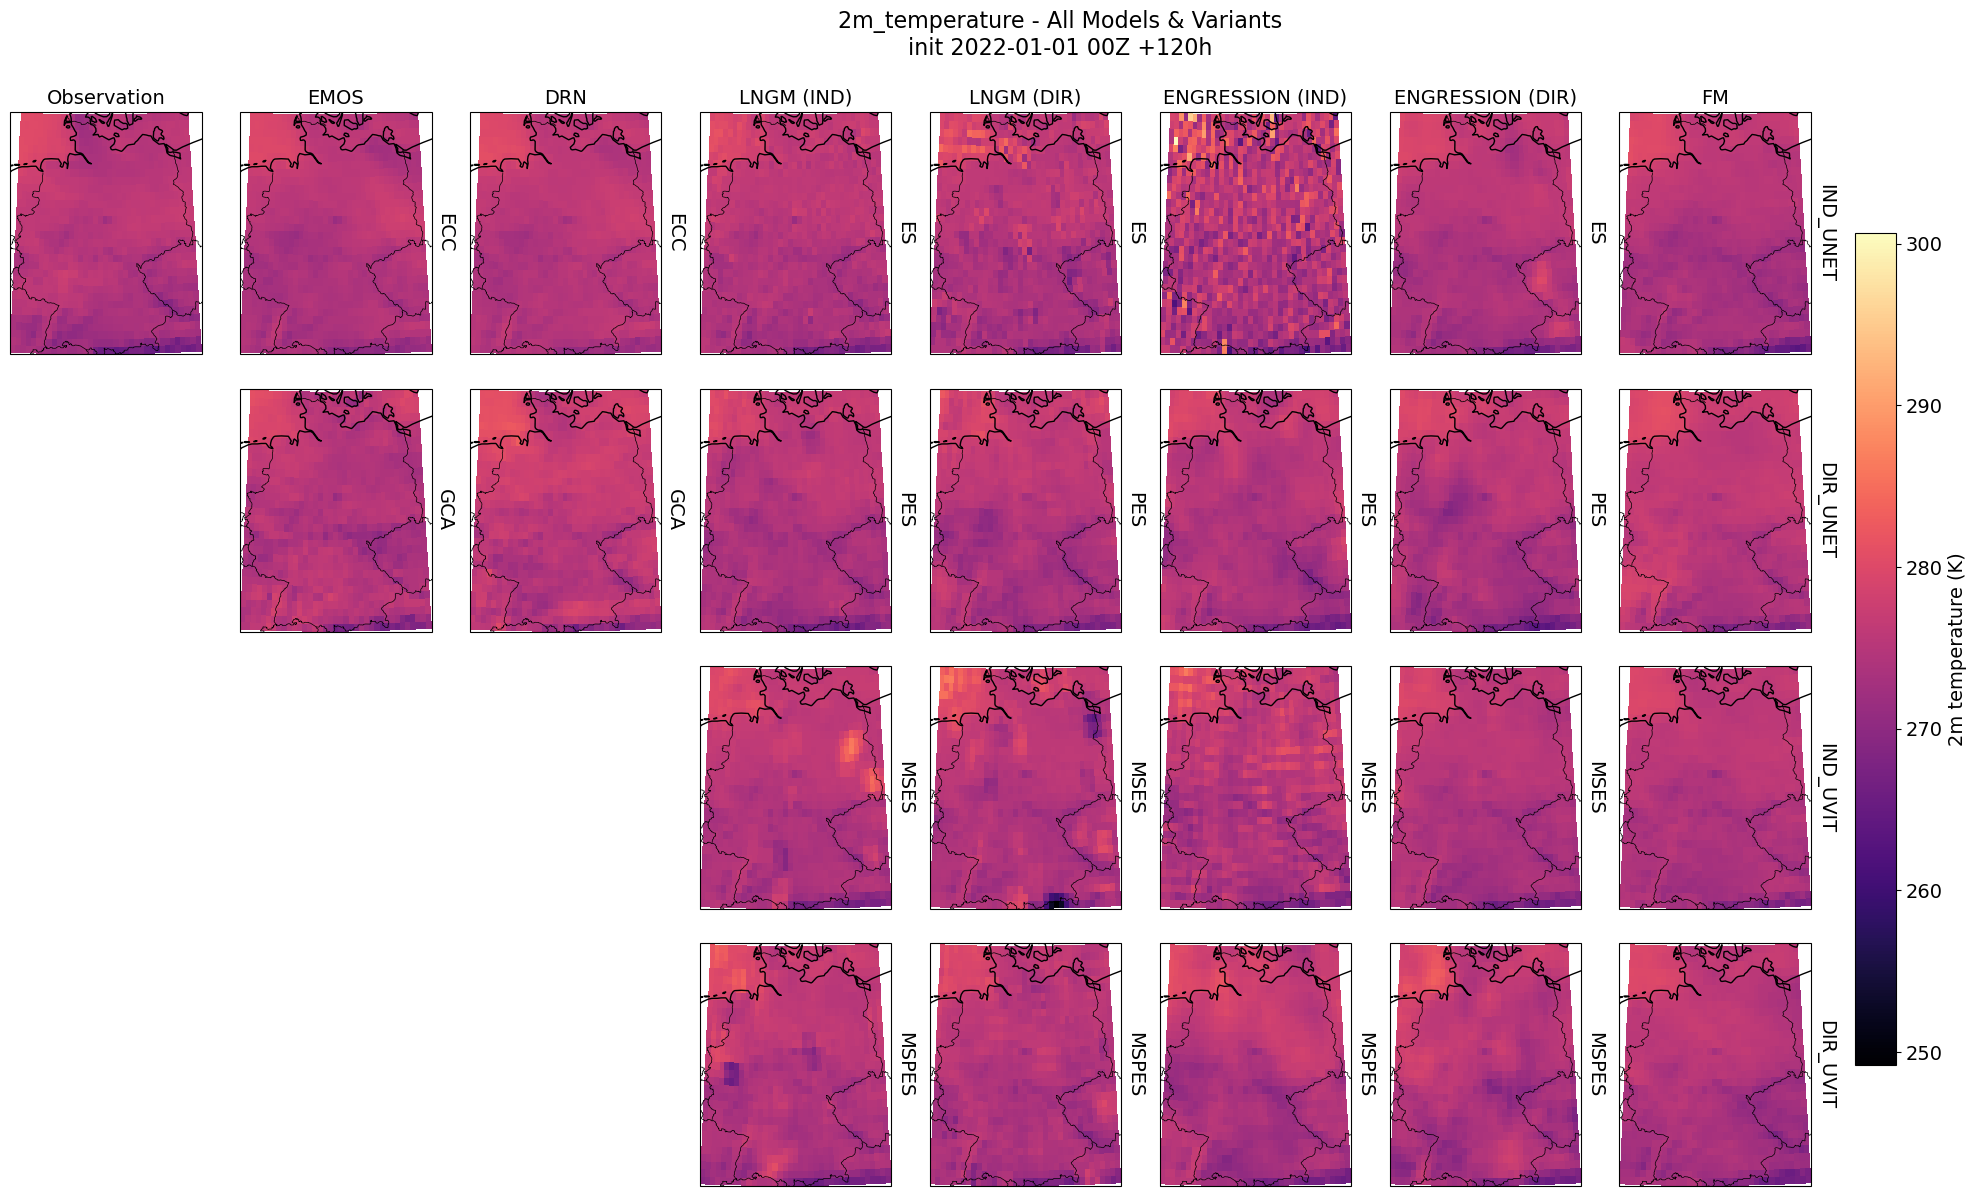

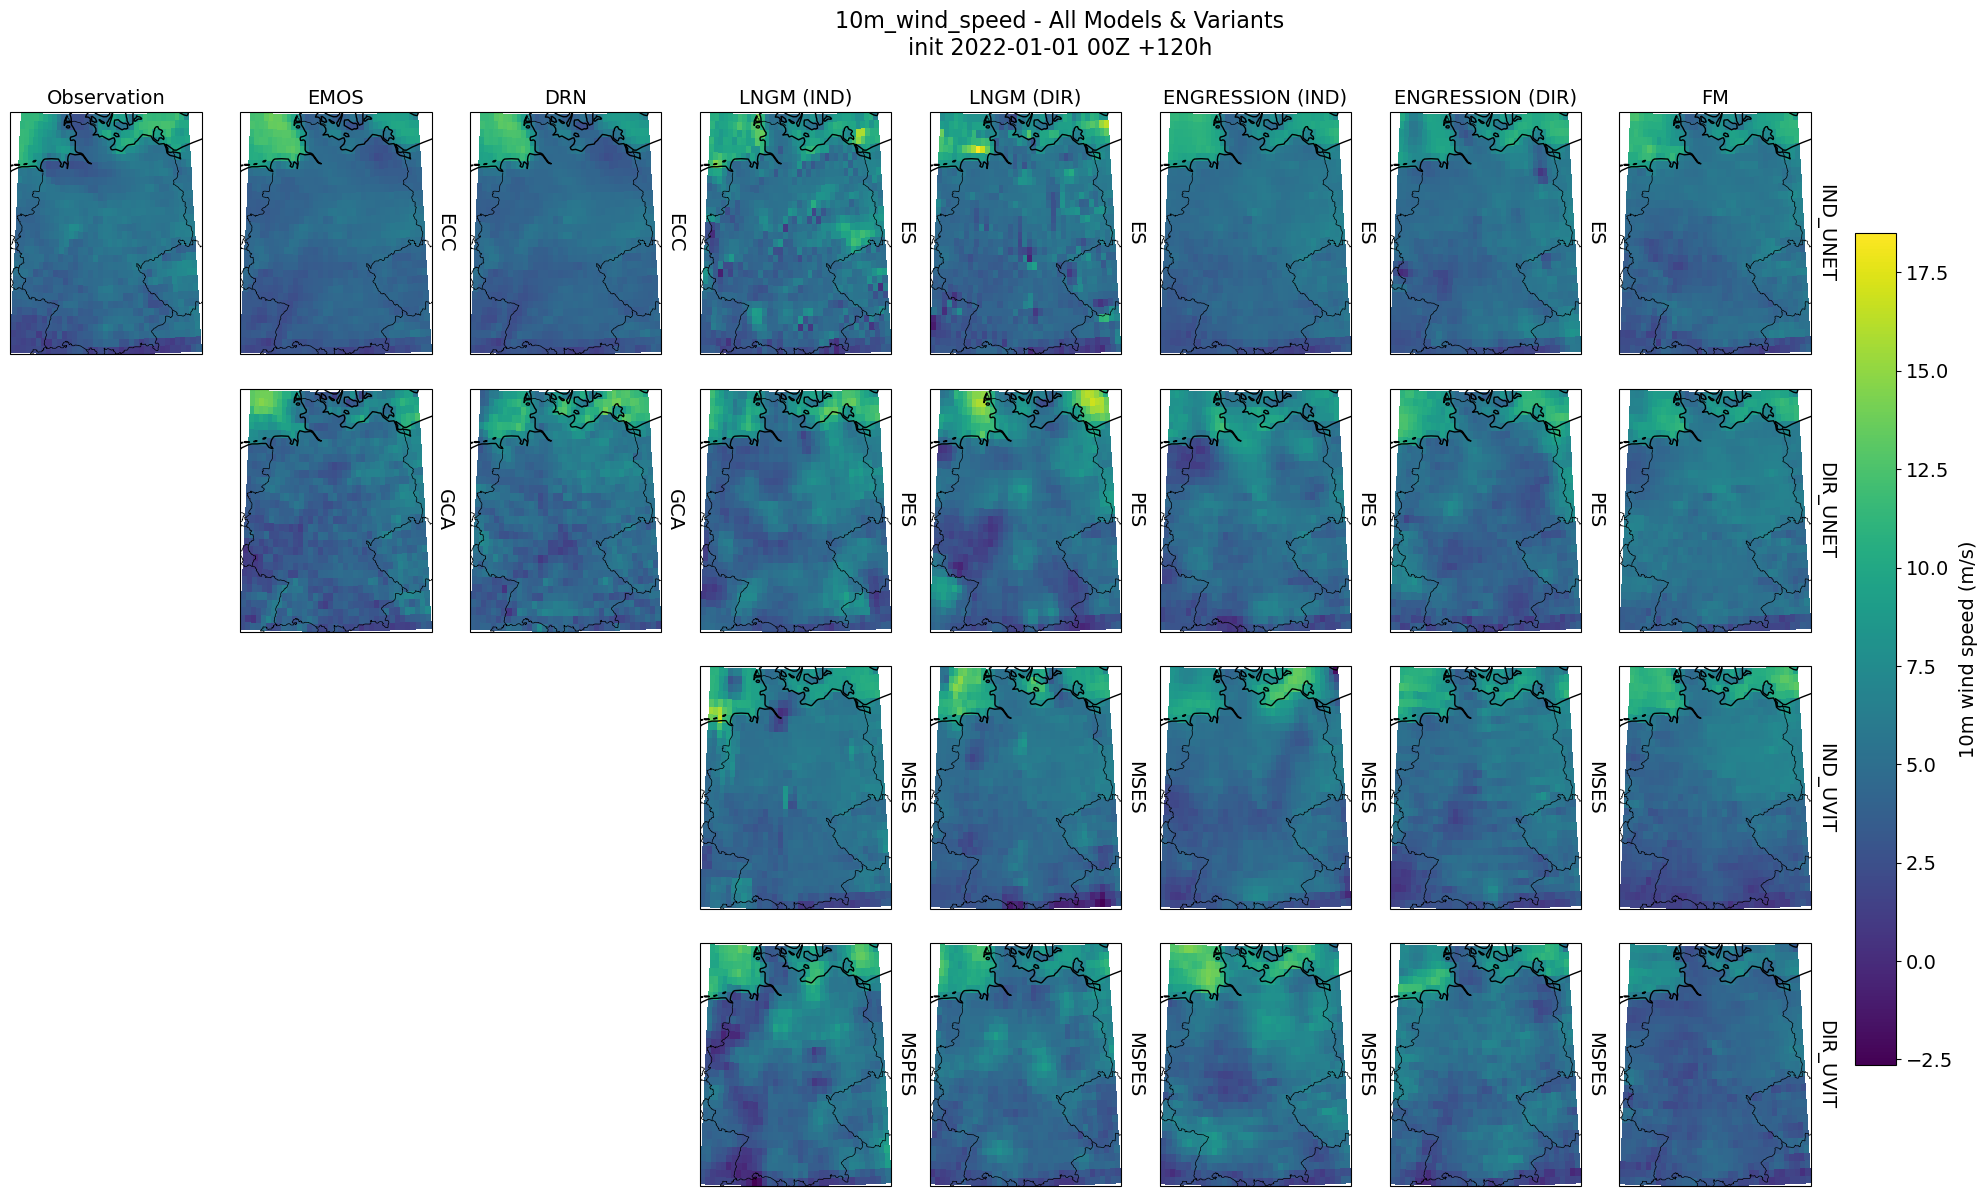

In [29]:
proj = ccrs.LambertConformal(central_longitude=10, central_latitude=51)

# Fixed model column order; each entry is (model_key, display_name, variant_prefix_filter or None)
MODEL_COLUMNS = [
    ("emos", "EMOS", None),
    ("drn", "DRN", None),
    ("chen", "LNGM (IND)", "ind_"),
    ("chen", "LNGM (DIR)", "dir_"),
    ("engression", "ENGRESSION (IND)", "ind_"),
    ("engression", "ENGRESSION (DIR)", "dir_"),
    ("fm", "FM", None),
]

for var in FC_VARS:
    cfg = var_settings[var]
    obs_v = obs_sel.sel(feature=var)

    # Build per-column variant lists
    col_variants: list[list[tuple[str, xr.DataArray]]] = []
    col_titles: list[str] = []
    for mkey, display, prefix in MODEL_COLUMNS:
        if mkey not in model_predictions or not model_predictions[mkey]:
            col_variants.append([])
            col_titles.append(display)
            continue
        entries = []
        for vname, vda in model_predictions[mkey].items():
            # Filter by prefix if specified
            if prefix is not None and not vname.startswith(prefix):
                continue
            da = vda.sel(prediction=sel_pred, feature=var)
            for dim in ("sample", "number", "member"):
                if dim in da.dims:
                    da = da.isel(**{dim: 0})
                    break
            # Strip prefix from display tag
            tag = vname[len(prefix) :] if prefix and vname.startswith(prefix) else vname
            entries.append((tag, da))
        col_variants.append(entries)
        col_titles.append(display)

    n_rows = max((len(v) for v in col_variants), default=1) or 1
    n_cols = 1 + len(MODEL_COLUMNS)  # Observation + model columns

    # Shared colour limits
    all_arrays = [obs_v]
    for entries in col_variants:
        all_arrays.extend(da for _, da in entries)
    all_vals = np.concatenate([d.values.ravel() for d in all_arrays])
    vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.5 * n_cols, 4.5 * n_rows),
        subplot_kw={"projection": proj},
    )
    fig.subplots_adjust(wspace=0.2, hspace=-0.5)
    axes = np.atleast_2d(axes)

    for row in range(n_rows):
        for col in range(n_cols):
            ax = axes[row, col]

            if col == 0:
                # Observation: only show in row 0, hide in other rows
                if row == 0:
                    pcm = ax.pcolormesh(
                        lon,
                        lat,
                        obs_v.T,
                        cmap=cfg["cmap"],
                        vmin=vmin,
                        vmax=vmax,
                        transform=ccrs.PlateCarree(),
                        shading="auto",
                        rasterized=True,
                    )
                    ax.coastlines(resolution="50m")
                    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
                    ax.set_title("Observation", fontsize=14)
                    ax.set_xticks([])
                    ax.set_yticks([])
                else:
                    ax.set_visible(False)
            else:
                entries = col_variants[col - 1]
                if row < len(entries):
                    tag, da = entries[row]
                    pcm = ax.pcolormesh(
                        lon,
                        lat,
                        da.T,
                        cmap=cfg["cmap"],
                        vmin=vmin,
                        vmax=vmax,
                        transform=ccrs.PlateCarree(),
                        shading="auto",
                        rasterized=True,
                    )
                    ax.coastlines(resolution="50m")
                    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
                    if row == 0:
                        ax.set_title(col_titles[col - 1], fontsize=14)
                    # Variant label on right side
                    if tag and tag != "standard":
                        ax.text(
                            1.02,
                            0.5,
                            tag.upper(),
                            transform=ax.transAxes,
                            fontsize=14,
                            va="center",
                            ha="left",
                            rotation=-90,
                        )
                    ax.set_xticks([])
                    ax.set_yticks([])
                else:
                    ax.set_visible(False)

    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="vertical",
        label=cfg["label"],
        shrink=0.6,
        pad=0.02,
    )
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(cfg["label"], fontsize=14)

    fig.suptitle(
        f"{var} - All Models & Variants\ninit {pd.Timestamp(sel_init):%Y-%m-%d %HZ} +{sel_lead_h}h",
        fontsize=16,
        y=0.85,
    )
    plt.savefig(
        RESULTS_DIR
        / "results"
        / "wb2"
        / "samples"
        / f"wb2_all_models_{var.replace(' ', '_')}_leadtime_{sel_lead_h}.pdf",
        bbox_inches="tight",
    )
    plt.show()

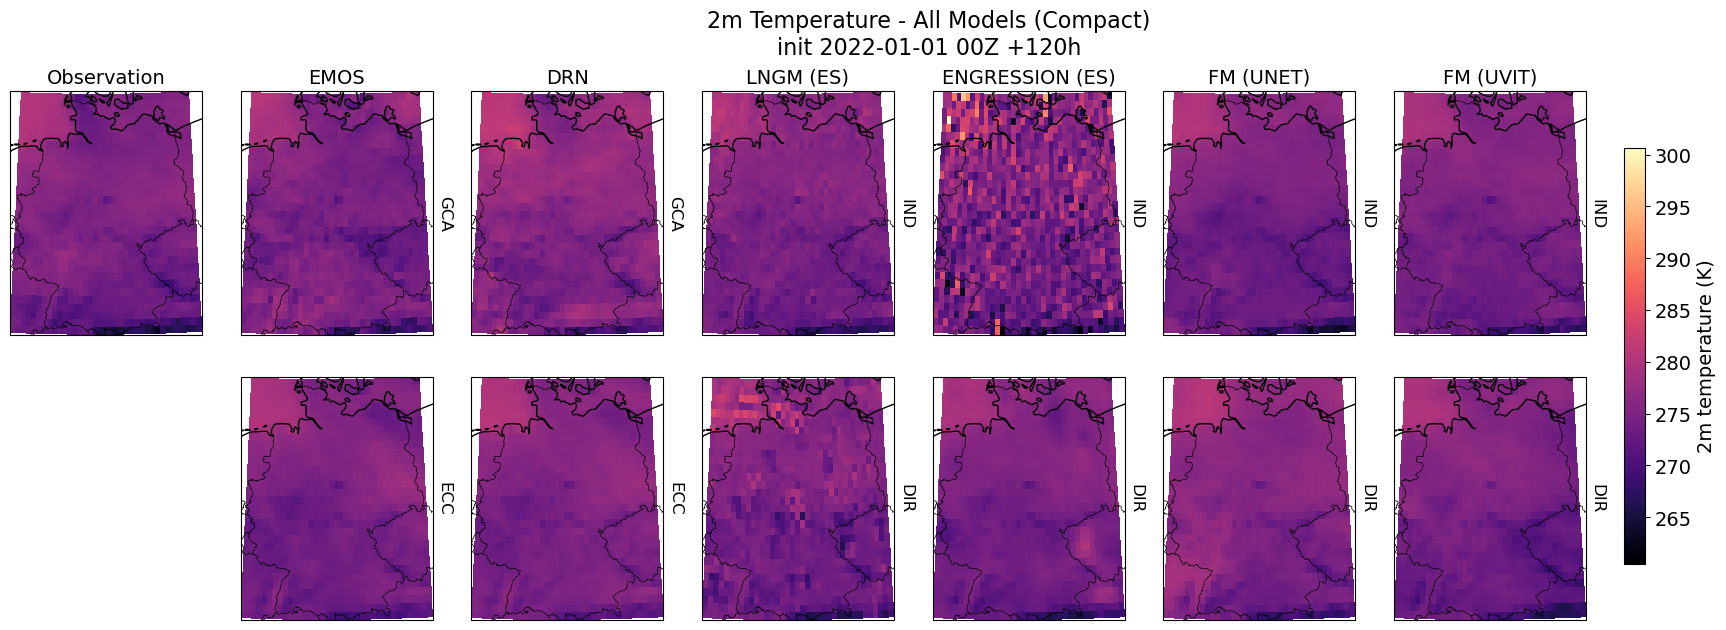

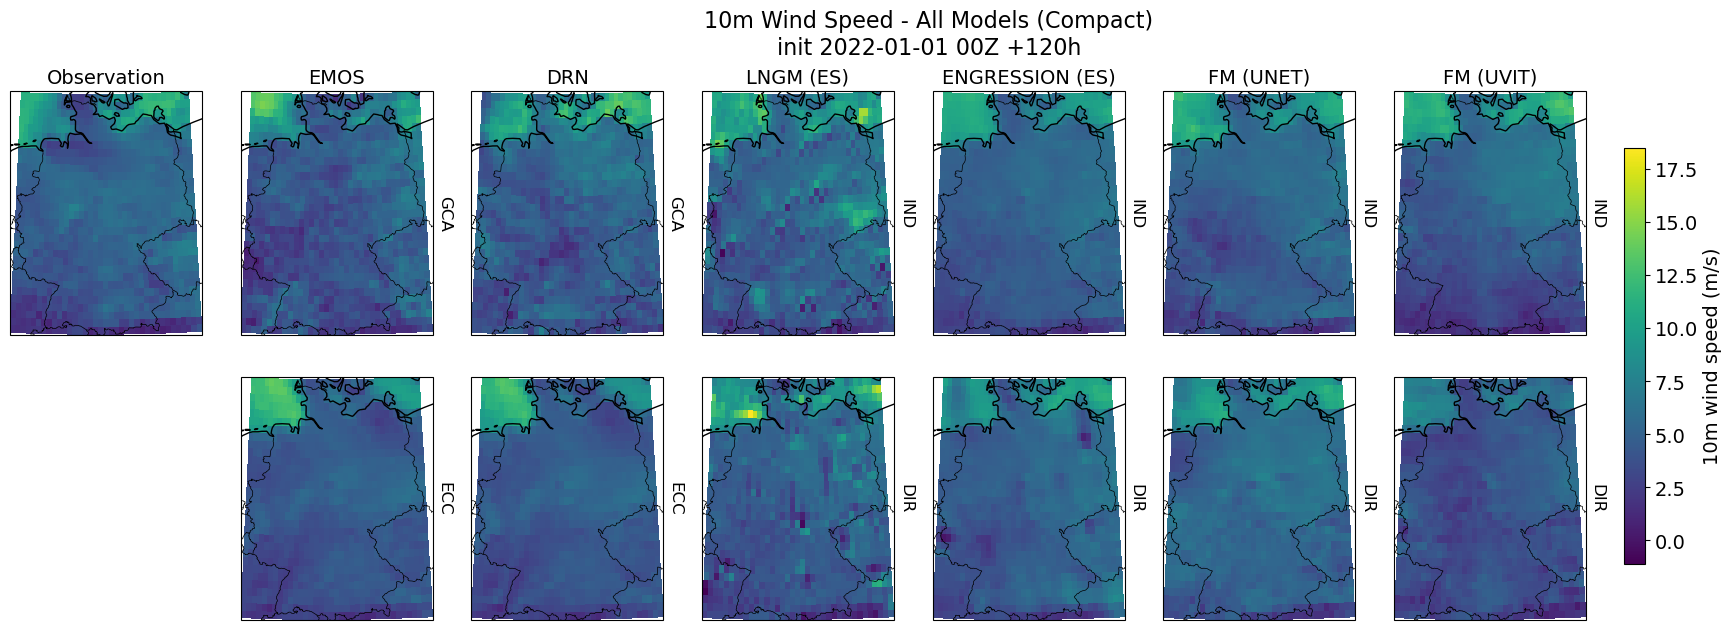

In [30]:
# Compact version: fewer columns, IND/DIR rows (GCA/ECC for EMOS/DRN)
# Each entry: (model_key, display_name, variant_filter, row_labels)
MODEL_COLUMNS_COMPACT = [
    ("emos", "EMOS", None, ["GCA", "ECC"]),
    ("drn", "DRN", None, ["GCA", "ECC"]),
    ("chen", "LNGM (ES)", "es", ["IND", "DIR"]),
    ("engression", "ENGRESSION (ES)", "es", ["IND", "DIR"]),
    ("fm", "FM (UNET)", "unet", ["IND", "DIR"]),
    ("fm", "FM (UVIT)", "uvit", ["IND", "DIR"]),
]

for var in FC_VARS:
    cfg = var_settings[var]
    obs_v = obs_sel.sel(feature=var)

    # Build per-column variant lists with explicit IND/DIR or GCA/ECC ordering
    col_variants: list[list[tuple[str, xr.DataArray]]] = []
    col_titles: list[str] = []
    col_row_labels: list[list[str]] = []

    for mkey, display, variant_filter, row_labels in MODEL_COLUMNS_COMPACT:
        col_titles.append(display)
        col_row_labels.append(row_labels)
        if mkey not in model_predictions or not model_predictions[mkey]:
            col_variants.append([])
            continue

        entries = []
        if mkey in ("emos", "drn"):
            # GCA then ECC order
            for copula in ("gca", "ecc"):
                if copula in model_predictions[mkey]:
                    da = model_predictions[mkey][copula].sel(prediction=sel_pred, feature=var)
                    for dim in ("sample", "number", "member"):
                        if dim in da.dims:
                            da = da.isel(**{dim: 0})
                            break
                    entries.append((copula, da))
        else:
            # IND then DIR, filtered by variant_filter (e.g. "es", "unet", "uvit")
            for direction in ("ind_", "dir_"):
                vname_target = (
                    f"{direction}{variant_filter}" if variant_filter else direction.rstrip("_")
                )
                if vname_target in model_predictions[mkey]:
                    da = model_predictions[mkey][vname_target].sel(prediction=sel_pred, feature=var)
                    for dim in ("sample", "number", "member"):
                        if dim in da.dims:
                            da = da.isel(**{dim: 0})
                            break
                    entries.append((direction.rstrip("_"), da))
        col_variants.append(entries)

    n_rows_c = max((len(v) for v in col_variants), default=1) or 1
    n_cols_c = 1 + len(MODEL_COLUMNS_COMPACT)  # Observation + model columns

    # Shared colour limits
    all_arrays = [obs_v]
    for entries in col_variants:
        all_arrays.extend(da for _, da in entries)
    all_vals = np.concatenate([d.values.ravel() for d in all_arrays])
    vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))

    fig, axes = plt.subplots(
        n_rows_c,
        n_cols_c,
        figsize=(3.5 * n_cols_c, 4.5 * n_rows_c),
        subplot_kw={"projection": proj},
    )
    fig.subplots_adjust(wspace=0.2, hspace=-0.3)
    axes = np.atleast_2d(axes)

    for row in range(n_rows_c):
        for col in range(n_cols_c):
            ax = axes[row, col]

            if col == 0:
                # Observation: only show in row 0
                if row == 0:
                    pcm = ax.pcolormesh(
                        lon,
                        lat,
                        obs_v.T,
                        cmap=cfg["cmap"],
                        vmin=vmin,
                        vmax=vmax,
                        transform=ccrs.PlateCarree(),
                        shading="auto",
                        rasterized=True,
                    )
                    ax.coastlines(resolution="50m")
                    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
                    ax.set_title("Observation", fontsize=14)
                    ax.set_xticks([])
                    ax.set_yticks([])
                else:
                    ax.set_visible(False)
            else:
                entries = col_variants[col - 1]
                row_labels = col_row_labels[col - 1]
                if row < len(entries):
                    tag, da = entries[row]
                    pcm = ax.pcolormesh(
                        lon,
                        lat,
                        da.T,
                        cmap=cfg["cmap"],
                        vmin=vmin,
                        vmax=vmax,
                        transform=ccrs.PlateCarree(),
                        shading="auto",
                        rasterized=True,
                    )
                    ax.coastlines(resolution="50m")
                    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
                    if row == 0:
                        ax.set_title(col_titles[col - 1], fontsize=14)
                    # Row label on right side
                    label = row_labels[row] if row < len(row_labels) else ""
                    if label:
                        ax.text(
                            1.02,
                            0.5,
                            label,
                            transform=ax.transAxes,
                            fontsize=12,
                            va="center",
                            ha="left",
                            rotation=-90,
                        )
                    ax.set_xticks([])
                    ax.set_yticks([])
                else:
                    ax.set_visible(False)

    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="vertical",
        label=cfg["label"],
        shrink=0.6,
        pad=0.02,
    )
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(cfg["label"], fontsize=14)

    VAR_DISPLAY_NAMES = {
        "2m_temperature": "2m Temperature",
        "10m_wind_speed": "10m Wind Speed",
    }
    fig.suptitle(
        f"{VAR_DISPLAY_NAMES.get(var, var)} - All Models (Compact)\ninit {pd.Timestamp(sel_init):%Y-%m-%d %HZ} +{sel_lead_h}h",
        fontsize=16,
        y=0.88,
    )
    plt.savefig(
        RESULTS_DIR
        / "results"
        / "wb2"
        / "samples"
        / f"wb2_all_models_{var.replace(' ', '_')}_leadtime_{sel_lead_h}_compact.pdf",
        bbox_inches="tight",
    )
    plt.show()